#### Problem statement: Develop a machine learning-based ventilation decision system that analyzes classroom occupancy and environmental conditions to predict whether ventilation is required, helping maintain healthy indoor air quality in schools.

#### Import libraries and understand dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize']=(10,5)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='viridis')

In [ ]:

df = pd.read_csv(r"C:\Users\dssas\OneDrive\Desktop\DS\GitHub Projects\Ensemble Learning\Random_forest_Bagging\air_quality-selected-columns.csv")
df.head()

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,12-11-2025 08:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE
1,12-11-2025 08:01,Morning Entry,6,444.6,5.08,21.0,44.8,2.2,4.0,IDLE
2,12-11-2025 08:03,Morning Entry,11,466.9,5.93,21.0,44.7,2.7,3.8,IDLE
3,12-11-2025 08:05,Morning Entry,6,483.6,5.49,21.0,44.6,2.7,3.8,IDLE
4,12-11-2025 08:06,Morning Entry,16,520.6,6.25,21.0,44.7,3.2,3.9,IDLE


In [9]:
df.shape

(500, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   timestamp                500 non-null    object 
 1   school_period            500 non-null    object 
 2   student_count_estimated  500 non-null    int64  
 3   co2_ppm                  500 non-null    float64
 4   pm25_ugm3                500 non-null    float64
 5   temperature_c            500 non-null    float64
 6   humidity_pct             500 non-null    float64
 7   robot_x_pos              500 non-null    float64
 8   robot_y_pos              500 non-null    float64
 9   ventilation_decision     500 non-null    object 
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [11]:
df.describe()

,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,11.184000,619.266400,8.439960,20.48980,44.594400,2.005800,1.990000
std,9.446301,155.967082,2.718404,0.19191,3.057506,1.415639,1.420781
min,0.000000,432.200000,4.400000,20.20000,41.300000,0.000000,0.000000
25%,3.000000,493.825000,6.170000,20.40000,41.800000,0.600000,0.600000
50%,7.000000,529.200000,7.080000,20.50000,42.800000,2.050000,2.000000
75%,22.000000,801.425000,11.512500,20.50000,47.800000,3.400000,3.400000
max,27.000000,893.000000,14.500000,21.00000,49.700000,4.000000,4.000000


In [13]:
df.dtypes

timestamp                   object
school_period               object
student_count_estimated      int64
co2_ppm                    float64
pm25_ugm3                  float64
temperature_c              float64
humidity_pct               float64
robot_x_pos                float64
robot_y_pos                float64
ventilation_decision        object
dtype: object

<Axes: >

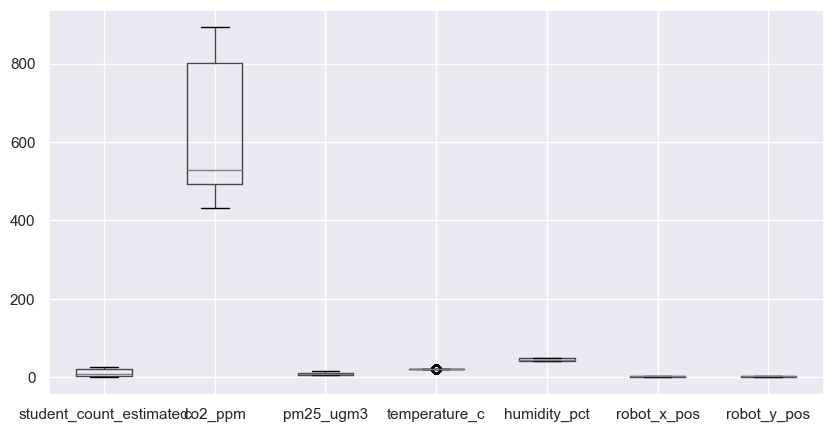

In [12]:
df.boxplot()

#### Exploratory Data Analysis (EDA)

#### Find null value

In [14]:
df.isna().sum()

timestamp                  0
school_period              0
student_count_estimated    0
co2_ppm                    0
pm25_ugm3                  0
temperature_c              0
humidity_pct               0
robot_x_pos                0
robot_y_pos                0
ventilation_decision       0
dtype: int64

#### find duplicate values

In [15]:
df.duplicated().sum()

np.int64(0)

#### Drop unnecessary columns

In [16]:
df.head(1)

,timestamp,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,12-11-2025 08:00,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE


In [17]:
df.drop(columns=['timestamp'], inplace=True)

In [18]:
df.head(1)

,school_period,student_count_estimated,co2_ppm,pm25_ugm3,temperature_c,humidity_pct,robot_x_pos,robot_y_pos,ventilation_decision
0,Morning Entry,11,442.1,5.16,21.0,45.0,2.0,4.0,IDLE


#### Encoding

In [30]:
categorical_col= df.select_dtypes(include=['object','string','category']).columns.tolist()

for col in categorical_col:
    print(f'\nUnique value in {categorical_col}')
    print(df[col].unique())


Unique value in ['school_period', 'ventilation_decision']
['Morning Entry' '1st Period' '2nd Period' 'Break' '3rd Period'
 '4th Period' 'Lunch Break' '5th Period' 'End of Day']

Unique value in ['school_period', 'ventilation_decision']
['IDLE' 'MONITOR']


##### One hot encoding

In [31]:
df=pd.get_dummies(df,columns=['school_period'],drop_first=True, dtype=int)

In [36]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['ventilation_decision']=le.fit_transform(df['ventilation_decision'])

#### find corelation between columns

co2_ppm                        0.948373
pm25_ugm3                      0.904557
humidity_pct                   0.883033
student_count_estimated        0.863871
school_period_End of Day      -0.792169
temperature_c                  0.461084
school_period_4th Period       0.390920
school_period_2nd Period       0.340433
school_period_3rd Period       0.307568
school_period_5th Period       0.307568
school_period_Morning Entry   -0.167676
robot_x_pos                   -0.164386
robot_y_pos                    0.040905
school_period_Break            0.000960
school_period_Lunch Break      0.000960
Name: ventilation_decision, dtype: float64


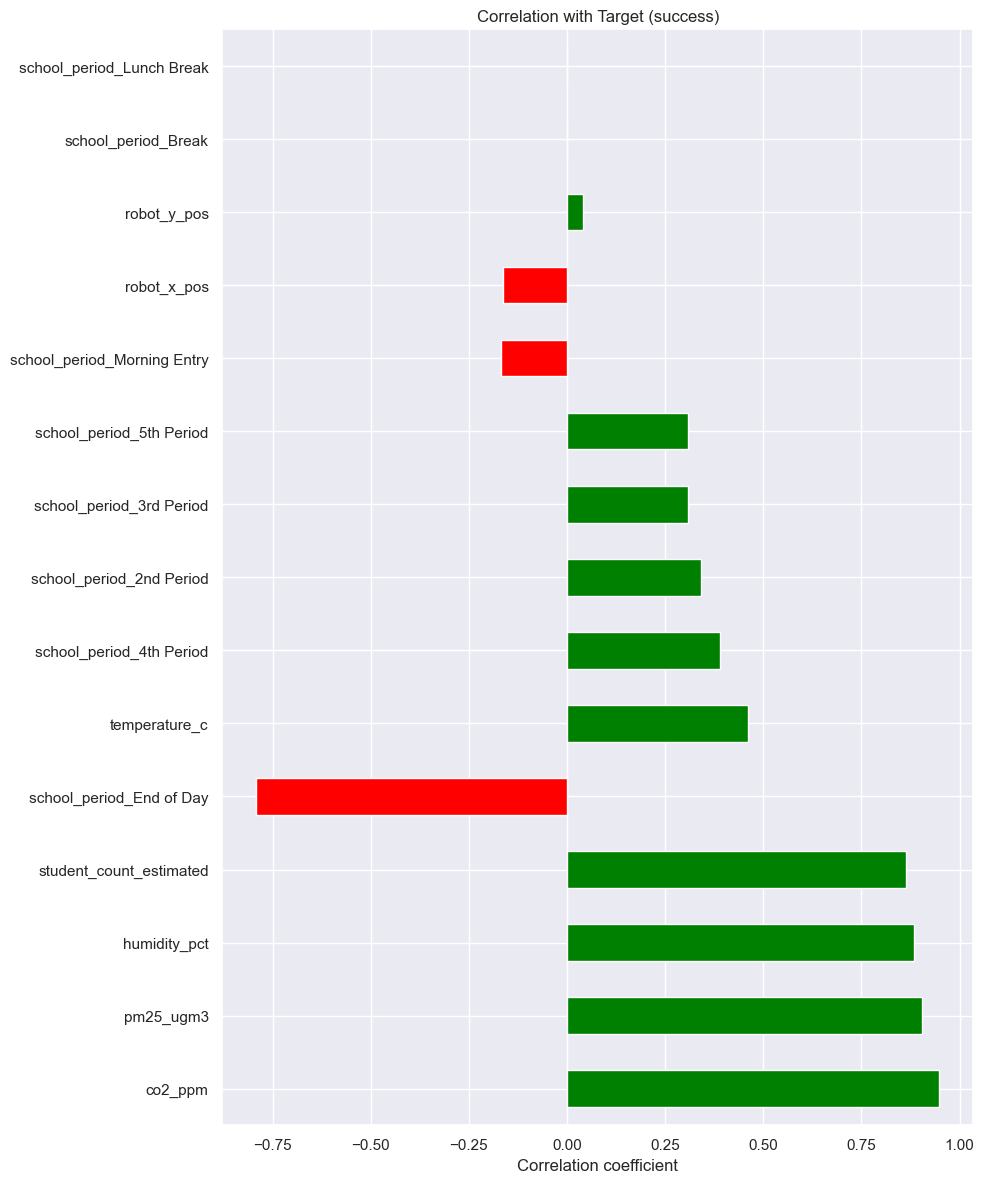

In [37]:
numeric_df = df.select_dtypes(include=[int,float])
target_corr = numeric_df.corr()['ventilation_decision'].drop('ventilation_decision').sort_values(key=abs, ascending=False)
print(target_corr)

plt.figure(figsize=(10,12))
target_corr.plot(kind='barh', color=['green' if v > 0 else 'red' for v in target_corr])
plt.title('Correlation with Target (success)')
plt.xlabel('Correlation coefficient')
plt.tight_layout()
plt.show()

In [40]:
Selected_features=['co2_ppm','pm25_ugm3','humidity_pct','student_count_estimated',
                   'school_period_End of Day','temperature_c',
                   'school_period_4th Period','school_period_2nd Period',
                   'school_period_3rd Period','school_period_5th Period']

Selected_features

['co2_ppm',
 'pm25_ugm3',
 'humidity_pct',
 'student_count_estimated',
 'school_period_End of Day',
 'temperature_c',
 'school_period_4th Period',
 'school_period_2nd Period',
 'school_period_3rd Period',
 'school_period_5th Period']

#### Define X and y

In [48]:
X=df[Selected_features]
y=df['ventilation_decision']
X

,co2_ppm,pm25_ugm3,humidity_pct,student_count_estimated,school_period_End of Day,temperature_c,school_period_4th Period,school_period_2nd Period,school_period_3rd Period,school_period_5th Period
0,442.1,5.16,45.0,11,0,21.0,0,0,0,0
1,444.6,5.08,44.8,6,0,21.0,0,0,0,0
2,466.9,5.93,44.7,11,0,21.0,0,0,0,0
3,483.6,5.49,44.6,6,0,21.0,0,0,0,0
4,520.6,6.25,44.7,16,0,21.0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
495,501.6,6.26,41.8,4,1,20.2,0,0,0,0
496,474.9,6.66,41.6,1,1,20.2,0,0,0,0
497,454.7,6.26,41.5,0,1,20.2,0,0,0,0
498,471.8,6.13,41.5,6,1,20.2,0,0,0,0


In [49]:
Xtrain,Xtest,ytrain,ytest= train_test_split(X,y,test_size=0.2,random_state=42)

In [50]:
rfc=RandomForestClassifier(random_state=42)
rfc.fit(Xtrain, ytrain)
yp=rfc.predict(Xtest)
yp

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0])

In [51]:
print(f'Training Accuracy: {rfc.score(Xtrain, ytrain)}')
print(f'Testing Accuracy: {rfc.score(Xtest, ytest)}')

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [52]:
from sklearn.metrics import classification_report, confusion_matrix
ypred= rfc.predict(Xtest)

print(classification_report(ytest,ypred))
print(confusion_matrix(ytest,ypred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        67
           1       1.00      1.00      1.00        33

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[67  0]
 [ 0 33]]


#### conclusion: The Random Forest Classifier achieved 100% accuracy on the test dataset, with perfect precision, recall, and F1-score for both classes. The confusion matrix shows zero false positives and false negatives.